Confusion matrix:
[[6 0]
 [0 6]]

Accuracy:
1.0

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



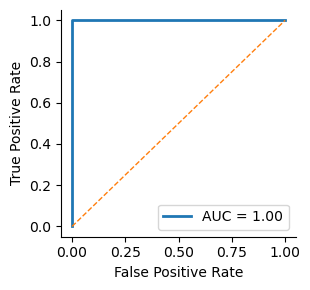

[[3 0]
 [0 3]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



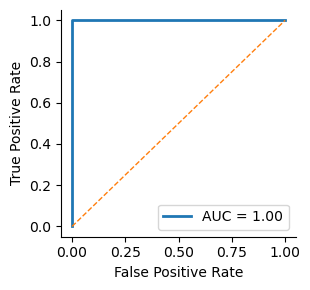

(1000, 647)
Any non-zero coefficients? True
Mean #nonzero per bootstrap: 57.494
Std  #nonzero per bootstrap: 11.454866389443398
                                           metabolite  mean_coef  std_coef  \
0   2-hydroxy-6-[2-hydroxy-6-(hydroxymethyl)-4-met...   0.010413  0.038676   
1                                          Kaempferol  -0.007485  0.023578   
2   1-chloro-3-{[(cyanoimino)(phenoxy)methyl]amino...   0.031657  0.141708   
3                  Flavonol 3-O-D-xylosylgalactoside;   0.326317  0.694058   
4                                          Dantrolene   0.020842  0.119076   
5                                           NP-004020   0.010442  0.054738   
6                                            2C-B-BZP   0.016284  0.090468   
7                                               Rutin  -0.019122  0.108631   
8                                          Astragalin  -0.012637  0.067419   
9                           Kaempferol-3-O-rutinoside  -0.006140  0.027234   
10  3-(4-nitro

ValueError: No engine for filetype: ''

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression

###################  Functions  ################### 

# Data encoding
def encodage(df):
    code = {
    Class_A : 0,
    Class_B : 1}
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)
    return df

# Data preprocessing
def preprocessing(df):
    df = encodage(df)
    X = df.drop(['Class'], axis = 1)
    y = df['Class']
    return X, y

# ROC curve plotting 
def AUC_plot(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(3.2,3.0))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--', lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    return roc_auc

# Cross-validation evaluation
def evaluation(model):
    cv = LeaveOneOut()
    y_pred = cross_val_predict(model, X_main, y_main, cv=cv)
    y_proba = cross_val_predict(model, X_main, y_main, cv=cv, method="predict_proba")[:,1]
    print("Confusion matrix:")
    print(confusion_matrix(y_main, y_pred))
    print("\nAccuracy:")
    print(round(accuracy_score(y_main, y_pred),3))
    print("\nClassification report:")
    print(classification_report(y_main, y_pred))
    roc_auc = AUC_plot(y_main, y_proba)
    return roc_auc


# External dataset evaluation
def evaluation_external(model):
    model.fit(X_main, y_main)
    ypred = model.predict(X_ext)
    y_score = model.predict_proba(X_ext)[:,1]
    print(confusion_matrix(y_ext, ypred))
    print(classification_report(y_ext, ypred))
    roc_auc = AUC_plot(y_ext, y_score)
    return roc_auc


# Parameters

# Choose classes between HL (healthy lemon), HO (healthy orange), IL (infected lemon), IO (infected orange)
Class_A = 'IL'
Class_B = 'IO'

# Data loading
df_main = pd.read_excel("path/to/main/dataset")
df_ext = pd.read_excel("path/to/external/dataset")

# Class filtering
df_main = df_main[(df_main["Class"] == Class_A) | (df_main["Class"] == Class_B)]
df_ext = df_ext[(df_ext["Class"] == Class_A) | (df_ext["Class"] == Class_B)]

# Data preprocessing
X_main, y_main = preprocessing(df_main)
X_ext, y_ext = preprocessing(df_ext)

# Model definition
log2_transformer = FunctionTransformer(lambda x: np.log2(x + 1))
log2_tmp = np.log2(X_main + 1)
vars_ = log2_tmp.var(axis=0)
q = np.quantile(vars_, 0.5)
selector = VarianceThreshold(threshold=q)

LR_L1 = make_pipeline(
    log2_transformer,
    selector,
    StandardScaler(),
    LogisticRegression(penalty='l1', random_state=0, solver='liblinear')
)

###################  Model evaluation  ################### 
# Cross-validation performance
evaluation(LR_L1)

# External validation performance
evaluation_external(LR_L1)

###################  Bootstrap stability analysis  ################### 
y_arr = np.asarray(y_main)
n_boot = 1000
n_features = X_main.shape[1]
coef_mat = np.zeros((n_boot, n_features))
for b in range(n_boot):
    idx_R = np.where(y_arr == 0)[0]
    idx_S = np.where(y_arr == 1)[0]
    boot_R = np.random.choice(idx_R, size=len(idx_R), replace=True)
    boot_S = np.random.choice(idx_S, size=len(idx_S), replace=True)
    boot_idx = np.concatenate([boot_R, boot_S])
    Xb = X_main.iloc[boot_idx]
    yb = y_arr[boot_idx]
    LR_L1.fit(Xb, yb)
    coefs = LR_L1.named_steps["logisticregression"].coef_[0]
    support = LR_L1.named_steps['variancethreshold'].get_support()
    full_coef = np.zeros(n_features)
    full_coef[support] = coefs
    coef_mat[b, :] = full_coef

# Bootstrap statistics
print(coef_mat.shape)
print("Any non-zero coefficients?", np.any(coef_mat != 0))
print("Mean #nonzero per bootstrap:", np.mean(np.sum(coef_mat != 0, axis=1)))
print("Std  #nonzero per bootstrap:", np.std(np.sum(coef_mat != 0, axis=1)))

coef_df = pd.DataFrame(coef_mat, columns=X_main.columns)
summary = pd.DataFrame({
    "metabolite": X_main.columns,
    "mean_coef": coef_df.mean(axis=0),
    "std_coef": coef_df.std(axis=0),
    "nonzero_freq": (coef_df != 0).mean(axis=0),
    "pos_freq": (coef_df > 0).mean(axis=0),
    "neg_freq": (coef_df < 0).mean(axis=0),
})

summary["sign_consistency"] = (summary["pos_freq"] - summary["neg_freq"]).abs()
summary["abs_mean_over_sd"] = summary["mean_coef"].abs() / (summary["std_coef"] + 1e-12)
summary = summary.sort_values(
    ["nonzero_freq", "sign_consistency", "abs_mean_over_sd"],
    ascending=[False, False, False]
).reset_index(drop=True)

print(summary.head(20))

# Export results
summary.to_excel("path/to/file", index=False)

# Mon code

Confusion matrix:
[[6 0]
 [0 6]]

Accuracy:
1.0

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



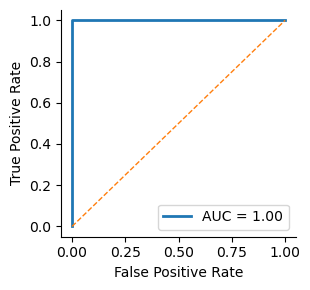

[[3 0]
 [0 3]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



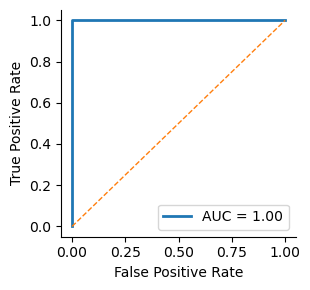

helooooo
(1000, 647)
Any non-zero coefficients? True
Mean #nonzero per bootstrap: 42.561
Std  #nonzero per bootstrap: 15.151774780533136
                                           metabolite  mean_coef  std_coef  \
0    [4-(2-methoxyphenyl)piperidino](phenyl)methanone   0.018149  0.040432   
1   Kaempferol 3-apiosyl-(1->4)-rhamnoside-7-rhamn...   0.014888  0.032141   
2                                             Didymin   0.035923  0.099927   
3   N1-Phenyl-2-{[2-(3-thienylmethyl)-1,3-thiazol-...   0.015639  0.031794   
4   N'-methyl-N'-(3-nitro-2-pyridyl)-(methylsulfon...   0.016582  0.046866   
5                                           NP-018873   0.012596  0.023676   
6   4-{[(morpholinosulfonyl)methyl]sulfonyl}morpho...   0.015249  0.030560   
7   N-[3,5-bis(trifluoromethyl)phenyl]-N'-[2-(2-ox...   0.014496  0.027195   
8                                      Adiantifoline;  -0.019411  0.050738   
9                                       Phenylephrine   0.014185  0.026852   
10   

ValueError: No engine for filetype: ''

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression

###################  Functions  ################### 

# Data encoding
def encodage(df):
    code = {
    Class_A : 0,
    Class_B : 1}
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)
    return df

# Data preprocessing
def preprocessing(df):
    df = encodage(df)
    X = df.drop(['Class'], axis = 1)
    y = df['Class']
    return X, y

# ROC curve plotting 
def AUC_plot(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(3.2,3.0))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--', lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    return roc_auc

# Cross-validation evaluation
def evaluation(model):
    cv = LeaveOneOut()
    y_pred = cross_val_predict(model, X_main, y_main, cv=cv)
    y_proba = cross_val_predict(model, X_main, y_main, cv=cv, method="predict_proba")[:,1]
    print("Confusion matrix:")
    print(confusion_matrix(y_main, y_pred))
    print("\nAccuracy:")
    print(round(accuracy_score(y_main, y_pred),3))
    print("\nClassification report:")
    print(classification_report(y_main, y_pred))
    roc_auc = AUC_plot(y_main, y_proba)
    return roc_auc


# External dataset evaluation
def evaluation_external(model):
    model.fit(X_main, y_main)
    ypred = model.predict(X_ext)
    y_score = model.predict_proba(X_ext)[:,1]
    print(confusion_matrix(y_ext, ypred))
    print(classification_report(y_ext, ypred))
    roc_auc = AUC_plot(y_ext, y_score)
    print("helooooo")
    return roc_auc


# Parameters

# Choose classes between HL (healthy lemon), HO (healthy orange), IL (infected lemon), IO (infected orange)
Class_A = 'LP'
Class_B = 'SP'

dataset = "C:/Users/tamer/Documents/PhD/ML/enhanced_metabolome.xlsx"
df_main = pd.read_excel(dataset, sheet_name = 'Paul_50%')
df_ext = pd.read_excel(dataset, sheet_name = 'Saqib_50%')

# Class filtering
df_main = df_main[(df_main["Class"] == Class_A) | (df_main["Class"] == Class_B)]
df_ext = df_ext[(df_ext["Class"] == Class_A) | (df_ext["Class"] == Class_B)]

# Data preprocessing
X_main, y_main = preprocessing(df_main)
X_ext, y_ext = preprocessing(df_ext)

# Model definition
log2_transformer = FunctionTransformer(lambda x: np.log2(x + 1))
log2_tmp = np.log2(X_main + 1)
vars_ = log2_tmp.var(axis=0)
q = np.quantile(vars_, 0.5)
selector = VarianceThreshold(threshold=q)

LR_L1 = make_pipeline(
    log2_transformer,
    selector,
    StandardScaler(),
    LogisticRegression(penalty='l1', random_state=0, solver='liblinear')
)

###################  Model evaluation  ################### 
# Cross-validation performance
evaluation(LR_L1)

# External validation performance
evaluation_external(LR_L1)

###################  Bootstrap stability analysis  ################### 
y_arr = np.asarray(y_main)
n_boot = 1000
n_features = X_main.shape[1]
coef_mat = np.zeros((n_boot, n_features))
for b in range(n_boot):
    idx_R = np.where(y_arr == 0)[0]
    idx_S = np.where(y_arr == 1)[0]
    boot_R = np.random.choice(idx_R, size=len(idx_R), replace=True)
    boot_S = np.random.choice(idx_S, size=len(idx_S), replace=True)
    boot_idx = np.concatenate([boot_R, boot_S])
    Xb = X_main.iloc[boot_idx]
    yb = y_arr[boot_idx]
    LR_L1.fit(Xb, yb)
    coefs = LR_L1.named_steps["logisticregression"].coef_[0]
    support = LR_L1.named_steps['variancethreshold'].get_support()
    full_coef = np.zeros(n_features)
    full_coef[support] = coefs
    coef_mat[b, :] = full_coef

# Bootstrap statistics
print(coef_mat.shape)
print("Any non-zero coefficients?", np.any(coef_mat != 0))
print("Mean #nonzero per bootstrap:", np.mean(np.sum(coef_mat != 0, axis=1)))
print("Std  #nonzero per bootstrap:", np.std(np.sum(coef_mat != 0, axis=1)))

coef_df = pd.DataFrame(coef_mat, columns=X_main.columns)
summary = pd.DataFrame({
    "metabolite": X_main.columns,
    "mean_coef": coef_df.mean(axis=0),
    "std_coef": coef_df.std(axis=0),
    "nonzero_freq": (coef_df != 0).mean(axis=0),
    "pos_freq": (coef_df > 0).mean(axis=0),
    "neg_freq": (coef_df < 0).mean(axis=0),
})

summary["sign_consistency"] = (summary["pos_freq"] - summary["neg_freq"]).abs()
summary["abs_mean_over_sd"] = summary["mean_coef"].abs() / (summary["std_coef"] + 1e-12)
summary = summary.sort_values(
    ["nonzero_freq", "sign_consistency", "abs_mean_over_sd"],
    ascending=[False, False, False]
).reset_index(drop=True)

print(summary.head(20))

# Export results
summary.to_excel("path/to/file", index=False)

In [13]:
import numpy
import pandas
import matplotlib
import sklearn

print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

numpy: 2.3.4
pandas: 2.2.3
matplotlib: 3.10.0
scikit-learn: 1.6.1
